<a href="https://colab.research.google.com/github/mritu2000-bit/landsat-l1-processing-pipeline-rajasthan/blob/main/landsat-l1-processing-pipeline_RJST.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [24]:
import rasterio
import numpy as np
import math

In [25]:
bands = {}
profile = None

for i in range(1, 10):
    with rasterio.open(f'/content/Data/subset_B{i}.TIF') as src:
        data = src.read(1).astype(np.float32)
        data[data == 0] = np.nan
        bands[i] = data
        if profile is None:
            profile = src.profile

    print(f"Band {i} — Min: {np.nanmin(bands[i]):.0f} Max: {np.nanmax(bands[i]):.0f}")

print("CRS:", profile['crs'])
print("All bands loaded.")

Band 1 — Min: 10399 Max: 16311
Band 2 — Min: 9456 Max: 16699
Band 3 — Min: 8300 Max: 17652
Band 4 — Min: 7453 Max: 19114
Band 5 — Min: 6690 Max: 25786
Band 6 — Min: 5915 Max: 62793
Band 7 — Min: 5641 Max: 65535
Band 8 — Min: 8615 Max: 17850
Band 9 — Min: 5013 Max: 7008
CRS: EPSG:32644
All bands loaded.


In [26]:
import os

In [27]:
import xml.etree.ElementTree as ET

mtl_path = '/content/Data/LC08_L1TP_141045_20260412_20260412_02_RT_MTL.xml'
tree = ET.parse(mtl_path)
root = tree.getroot()

# Extract scaling factors for all bands
for elem in root.iter():
    if 'RADIANCE_MULT_BAND' in elem.tag or 'RADIANCE_ADD_BAND' in elem.tag or 'REFLECTANCE_MULT_BAND' in elem.tag or 'REFLECTANCE_ADD_BAND' in elem.tag or 'SUN_ELEVATION' in elem.tag or 'SUN_AZIMUTH' in elem.tag:
        print(elem.tag, ':', elem.text)

SUN_AZIMUTH : 115.69357831
SUN_ELEVATION : 63.52048637
RADIANCE_MULT_BAND_1 : 1.2497E-02
RADIANCE_MULT_BAND_2 : 1.2797E-02
RADIANCE_MULT_BAND_3 : 1.1793E-02
RADIANCE_MULT_BAND_4 : 9.9443E-03
RADIANCE_MULT_BAND_5 : 6.0854E-03
RADIANCE_MULT_BAND_6 : 1.5134E-03
RADIANCE_MULT_BAND_7 : 5.1009E-04
RADIANCE_MULT_BAND_8 : 1.1254E-02
RADIANCE_MULT_BAND_9 : 2.3783E-03
RADIANCE_MULT_BAND_10 : 3.3420E-04
RADIANCE_MULT_BAND_11 : 3.3420E-04
RADIANCE_ADD_BAND_1 : -62.48697
RADIANCE_ADD_BAND_2 : -63.98741
RADIANCE_ADD_BAND_3 : -58.96386
RADIANCE_ADD_BAND_4 : -49.72164
RADIANCE_ADD_BAND_5 : -30.42717
RADIANCE_ADD_BAND_6 : -7.56696
RADIANCE_ADD_BAND_7 : -2.55047
RADIANCE_ADD_BAND_8 : -56.27122
RADIANCE_ADD_BAND_9 : -11.89163
RADIANCE_ADD_BAND_10 : 0.10000
RADIANCE_ADD_BAND_11 : 0.10000
REFLECTANCE_MULT_BAND_1 : 2.0000E-05
REFLECTANCE_MULT_BAND_2 : 2.0000E-05
REFLECTANCE_MULT_BAND_3 : 2.0000E-05
REFLECTANCE_MULT_BAND_4 : 2.0000E-05
REFLECTANCE_MULT_BAND_5 : 2.0000E-05
REFLECTANCE_MULT_BAND_6 : 2.0000E-05

In [28]:
ML = {
    1: 1.2497E-02, 2: 1.2797E-02, 3: 1.1793E-02,
    4: 9.9443E-03, 5: 6.0854E-03, 6: 1.5134E-03,
    7: 5.1009E-04, 8: 1.1254E-02, 9: 2.3783E-03
}

AL = {
    1: -62.48697, 2: -63.98741, 3: -58.96386,
    4: -49.72164, 5: -30.42717, 6: -7.56696,
    7: -2.55047,  8: -56.27122, 9: -11.89163
}

Mp = {i: 2.0000E-05 for i in range(1, 10)}
Ap = {i: -0.100000 for i in range(1, 10)}
sun_elevation = 63.52048637

atm_params = {
    1: {'intrinsic': 0.089, 'gas_trans': 0.921, 'sph_albedo': 0.142},
    2: {'intrinsic': 0.060, 'gas_trans': 0.935, 'sph_albedo': 0.112},
    3: {'intrinsic': 0.041, 'gas_trans': 0.940, 'sph_albedo': 0.096},
    4: {'intrinsic': 0.035, 'gas_trans': 0.943, 'sph_albedo': 0.089},
    5: {'intrinsic': 0.015, 'gas_trans': 0.958, 'sph_albedo': 0.054},
    6: {'intrinsic': 0.005, 'gas_trans': 0.969, 'sph_albedo': 0.021},
    7: {'intrinsic': 0.003, 'gas_trans': 0.972, 'sph_albedo': 0.014},
    8: {'intrinsic': 0.044, 'gas_trans': 0.939, 'sph_albedo': 0.098},
    9: {'intrinsic': 0.008, 'gas_trans': 0.965, 'sph_albedo': 0.028}
}

surface = {}
for i in range(1, 10):
    band = bands[i].copy()
    toa = (Mp[i] * band + Ap[i]) / math.sin(math.radians(sun_elevation))
    toa[toa > 1] = np.nan
    toa[toa < 0] = np.nan
    p = atm_params[i]
    y = toa - p['intrinsic']
    sr = y / (p['gas_trans'] * (1 + p['sph_albedo'] * y))
    sr[sr > 1] = np.nan
    sr[sr < 0] = np.nan
    surface[i] = sr
    print(f"Band {i} — TOA Mean: {np.nanmean(toa):.4f} Surface Mean: {np.nanmean(sr):.4f}")

print("All bands corrected.")

Band 1 — TOA Mean: 0.1416 Surface Mean: 0.0567
Band 2 — TOA Mean: 0.1240 Surface Mean: 0.0679
Band 3 — TOA Mean: 0.1140 Surface Mean: 0.0771
Band 4 — TOA Mean: 0.1136 Surface Mean: 0.0827
Band 5 — TOA Mean: 0.2134 Surface Mean: 0.2048
Band 6 — TOA Mean: 0.2154 Surface Mean: 0.2161
Band 7 — TOA Mean: 0.1566 Surface Mean: 0.1577
Band 8 — TOA Mean: 0.1271 Surface Mean: 0.0878
Band 9 — TOA Mean: 0.0013 Surface Mean: 0.0351
All bands corrected.


In [29]:
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors

In [30]:
# NDVI calculation
nir = surface[5]
red = surface[4]

ndvi = (nir - red) / (nir + red)
ndvi[ndvi > 1] = np.nan
ndvi[ndvi < -1] = np.nan

print("NDVI Min:", round(np.nanmin(ndvi), 4))
print("NDVI Max:", round(np.nanmax(ndvi), 4))
print("NDVI Mean:", round(np.nanmean(ndvi), 4))

NDVI Min: -0.3827
NDVI Max: 0.8474
NDVI Mean: 0.4265


In [31]:
# Raw Band 4
axes[0].imshow(bands[4], cmap='gray')
axes[0].set_title('Raw DN - Band 4 (Red)')

Text(0.5, 1.0, 'Raw DN - Band 4 (Red)')

In [32]:
# Surface Reflectance Band 4
axes[1].imshow(surface[4], cmap='gray', vmin=0, vmax=0.3)
axes[1].set_title('Surface Reflectance - Band 4')

Text(0.5, 1.0, 'Surface Reflectance - Band 4')

In [33]:
# NDVI
ndvi_plot = axes[2].imshow(ndvi, cmap='RdYlGn', vmin=-0.2, vmax=0.8)
axes[2].set_title('NDVI')
plt.colorbar(ndvi_plot, ax=axes[2])

/tmp/ipykernel_3187/2543955827.py:4: UserWarning: Adding colorbar to a different Figure <Figure size 1800x600 with 4 Axes> than <Figure size 640x480 with 0 Axes> which fig.colorbar is called on.
  plt.colorbar(ndvi_plot, ax=axes[2])


<Figure size 640x480 with 0 Axes>

In [34]:
plt.tight_layout()
plt.savefig('/content/ndvi_result.png', dpi=150)
plt.show()
print("NDVI visualization saved.")

<Figure size 640x480 with 0 Axes>

NDVI visualization saved.


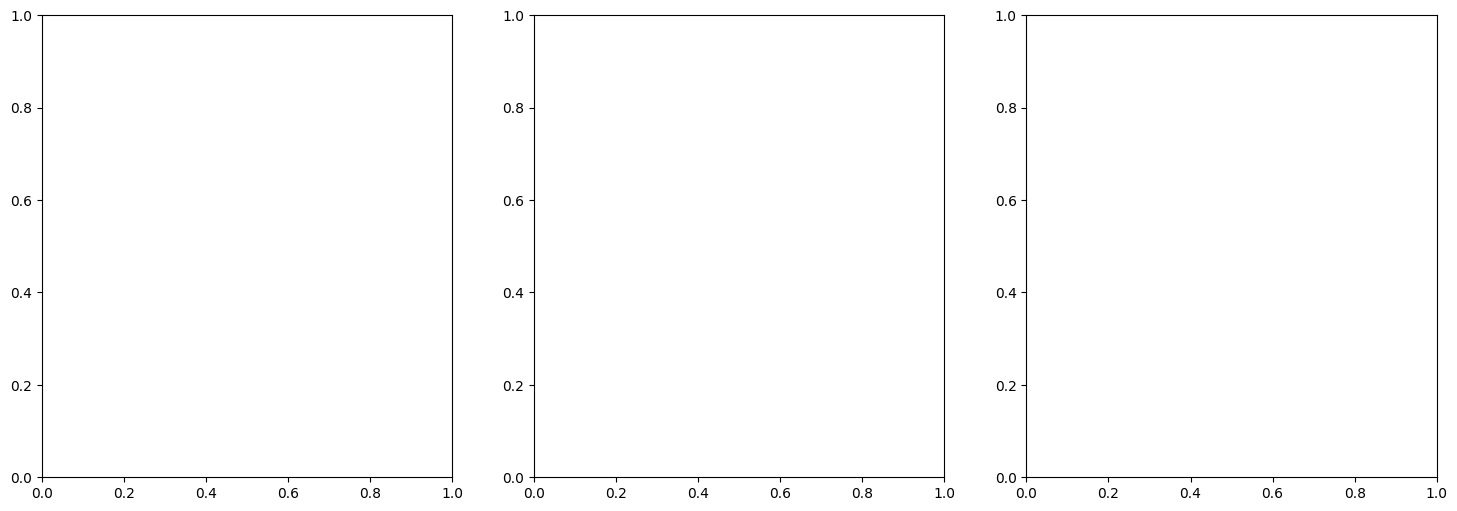

In [35]:
# Visualization
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

In [36]:
print("Band 4 sample values:", bands[4][100:105, 100:105])
print("Surface 4 sample values:", surface[4][100:105, 100:105])
print("NDVI sample values:", ndvi[100:105, 100:105])

Band 4 sample values: [[11023. 11853. 11542. 11316. 11359.]
 [10879. 10948. 10846. 11051. 10739.]
 [11304. 10865. 10610. 10923. 10547.]
 [11256. 11363. 10428. 11198. 10220.]
 [11074. 11381. 10482. 10985. 10602.]]
Surface 4 sample values: [[0.10466947 0.12396043 0.11673954 0.11148664 0.11248641]
 [0.10131618 0.10292319 0.10054744 0.10532127 0.09805419]
 [0.11120759 0.10099006 0.09504694 0.10234099 0.09357769]
 [0.11009124 0.11257943 0.0908015  0.10874209 0.08594586]
 [0.10585663 0.11299786 0.09206146 0.10378475 0.09486037]]
NDVI sample values: [[0.43887407 0.35186124 0.36429057 0.36703375 0.36135548]
 [0.40486565 0.40432596 0.41155162 0.38117453 0.39450085]
 [0.35168684 0.43209532 0.4458109  0.41223562 0.4221626 ]
 [0.37755394 0.36849627 0.46143636 0.41291738 0.42595148]
 [0.34221378 0.32200703 0.42589086 0.4087111  0.3816159 ]]


In [37]:
import matplotlib
matplotlib.use('Agg')
import matplotlib.pyplot as plt
import numpy as np

fig, axes = plt.subplots(1, 3, figsize=(18, 6))

# Raw Band 4
axes[0].imshow(bands[4], cmap='gray')
axes[0].set_title('Raw DN - Band 4 (Red)')
axes[0].axis('off')

# Surface Reflectance Band 4
axes[1].imshow(surface[4], cmap='gray', vmin=0, vmax=0.3)
axes[1].set_title('Surface Reflectance - Band 4')
axes[1].axis('off')

# NDVI
ndvi_plot = axes[2].imshow(ndvi, cmap='RdYlGn', vmin=-0.2, vmax=0.8)
axes[2].set_title('NDVI')
axes[2].axis('off')
plt.colorbar(ndvi_plot, ax=axes[2])

plt.tight_layout()
plt.savefig('/content/ndvi_result.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved.")

Saved.
